# 2주차 실습: 자연어와 텍스트 데이터 이해 — 제출용

**과목:** 자연어처리(NLP)  
**환경:** Google Colab / Python 3

## 오늘의 목표
1. 텍스트 데이터를 표 형태로 불러오고 구조를 점검한다.
2. 문서·문장·토큰 등 텍스트 데이터의 기본 단위를 구분한다.
3. 길이, 빈도, 어휘 다양성 등 기초 탐색적 텍스트 분석을 수행한다.
4. 한글 텍스트와 UTF-8 인코딩·유니코드 정규화 이슈를 확인한다.
5. 분석 전 데이터 품질·개인정보·저작권 관점을 점검한다.

## 작성 및 검증 기록
- 강의 PDF와 강의 음성의 STT 녹취를 참고해 TODO, 체크포인트, 도전 과제를 작성했다.
- 생성형 AI는 코드 초안 작성과 설명 문장 정리에 사용했으며, 전체 셀을 순서대로 실행해 오류 여부와 출력값을 검증했다.
- 데이터는 노트북에 포함된 교육용 자체 작성 예시만 사용했으며 외부 데이터셋은 추가하지 않았다.


## 0. 실습 데이터 소개

이번 실습에서는 온라인 영화 리뷰를 축약한 **교육용 예시 데이터**를 사용합니다. 실제 프로젝트에서는 데이터의 출처, 수집일, 이용 조건, 개인정보 포함 여부를 반드시 확인해야 합니다.

In [1]:
import re
import unicodedata
from collections import Counter
import pandas as pd

reviews = [
    (1, '정말 재미있어요! 배우들의 연기가 인상적이었습니다.', 1, '2026-08-25'),
    (2, '스토리는 평범하지만 음악이 좋네요.', 1, '2026-08-25'),
    (3, '기대보다 지루했고 결말이 아쉬웠습니다.', 0, '2026-08-26'),
    (4, '영상미는 훌륭합니다. 다만 전개가 조금 느려요.', 1, '2026-08-26'),
    (5, '다시는 보고 싶지 않은 영화예요...', 0, '2026-08-27'),
    (6, '가족과 함께 보기 좋은 따뜻한 작품입니다 :)', 1, '2026-08-27'),
    (7, '배우는 좋았지만 대사가 잘 들리지 않았어요.', 0, '2026-08-28'),
    (8, '추천합니다! 다음 편도 꼭 보고 싶어요.', 1, '2026-08-28'),
    (9, '별로예요. 러닝타임이 너무 길게 느껴집니다.', 0, '2026-08-29'),
    (10, '생각할 거리를 주는 좋은 영화였습니다.', 1, '2026-08-29'),
]

df = pd.DataFrame(reviews, columns=['review_id', 'text', 'label', 'date'])

# TODO 1. label 값(1, 0)을 각각 '긍정', '부정'으로 바꾼 label_name 열 생성
df['label_name'] = df['label'].map({1: '긍정', 0: '부정'})

df


,review_id,text,label,date,label_name
0,1,정말 재미있어요! 배우들의 연기가 인상적이었습니다.,1,2026-08-25,긍정
1,2,스토리는 평범하지만 음악이 좋네요.,1,2026-08-25,긍정
2,3,기대보다 지루했고 결말이 아쉬웠습니다.,0,2026-08-26,부정
3,4,영상미는 훌륭합니다. 다만 전개가 조금 느려요.,1,2026-08-26,긍정
4,5,다시는 보고 싶지 않은 영화예요...,0,2026-08-27,부정
5,6,가족과 함께 보기 좋은 따뜻한 작품입니다 :),1,2026-08-27,긍정
6,7,배우는 좋았지만 대사가 잘 들리지 않았어요.,0,2026-08-28,부정
7,8,추천합니다! 다음 편도 꼭 보고 싶어요.,1,2026-08-28,긍정
8,9,별로예요. 러닝타임이 너무 길게 느껴집니다.,0,2026-08-29,부정
9,10,생각할 거리를 주는 좋은 영화였습니다.,1,2026-08-29,긍정


## 1. 텍스트 데이터의 기본 단위

- **코퍼스(corpus)**: 분석을 위해 모은 텍스트 전체
- **문서(document)**: 코퍼스를 구성하는 개별 텍스트 (여기서는 리뷰 한 건)
- **문장(sentence)**: 문서 안의 의미 단위
- **토큰(token)**: 분석을 위해 나눈 단위. 단어, 형태소, 서브워드 등이 될 수 있음

같은 문장도 토큰화 규칙에 따라 결과가 달라집니다. 지금은 원리를 이해하기 위해 간단한 정규표현식 토크나이저를 사용합니다.

In [2]:
sample = df.loc[0, 'text']
print('원문:', sample)
print('공백 기준:', sample.split())

# TODO 2. 한글·영문·숫자로 이루어진 덩어리만 추출
regex_tokens = re.findall(r'[가-힣A-Za-z0-9]+', sample)
print('간단 정규표현식:', regex_tokens)


원문: 정말 재미있어요! 배우들의 연기가 인상적이었습니다.
공백 기준: ['정말', '재미있어요!', '배우들의', '연기가', '인상적이었습니다.']
간단 정규표현식: ['정말', '재미있어요', '배우들의', '연기가', '인상적이었습니다']


### 체크포인트 1 — 분석 단위 답변

공백 기준 토큰화에서는 `재미있어요!`처럼 문장부호가 단어에 붙어 남지만, 정규표현식 토큰화에서는 `재미있어요`만 추출되어 느낌표가 제거된다. 다만 둘 다 `연기가`의 조사나 `인상적이었습니다`의 어미를 분리하지 못하므로, 실제 한글 분석에서는 어근·조사·어미를 구분해 표현 변형으로 인한 토큰 분산을 줄일 수 있는 형태소 분석기(Kiwi, KoNLPy 등)가 필요하다.


### 체크포인트 1 — 요약

- 공백 토큰화: `재미있어요!` (문장부호 포함)
- 정규표현식 토큰화: `재미있어요` (문장부호 제외)
- 한글은 조사와 어미가 어절에 붙으므로 의미 단위를 더 안정적으로 비교하려면 형태소 분석이 필요하다.


## 2. 데이터 구조와 결측치 점검

분석을 시작하기 전에 행 수, 열의 의미, 자료형, 결측치, 중복을 확인합니다. 이 단계는 모델링보다 앞서 수행해야 합니다.

In [3]:
print('데이터 크기:', df.shape)
print('자료형:')
display(df.dtypes)
print('결측치 수:')
display(df.isna().sum())

# TODO 3. text 열에서 중복된 리뷰 개수 출력
print('중복 리뷰 수:', df['text'].duplicated().sum())

print('라벨 분포:')
display(df['label_name'].value_counts())


데이터 크기: (10, 5)
자료형:


review_id      int64
text          object
label          int64
date          object
label_name    object
dtype: object

결측치 수:


review_id     0
text          0
label         0
date          0
label_name    0
dtype: int64

중복 리뷰 수: 0
라벨 분포:


label_name
긍정    6
부정    4
Name: count, dtype: int64

In [4]:
# @title Colab에서 한글 폰트 설치 (환경에 따라 건너뜀)
import shutil
import subprocess

if shutil.which('apt-get'):
    subprocess.run(['apt-get', 'update', '-qq'], check=True)
    subprocess.run(['apt-get', 'install', '-y', 'fonts-nanum'], check=True)
    if shutil.which('fc-cache'):
        subprocess.run(['fc-cache', '-fv'], check=True, stdout=subprocess.DEVNULL)
    print('Nanum 글꼴 설치 완료')
else:
    print('apt-get이 없는 환경이므로 시스템 한글 글꼴을 사용합니다.')


apt-get이 없는 환경이므로 시스템 한글 글꼴을 사용합니다.


In [5]:
# @title matplotlib 한글 깨짐 방지 설정
import os
import matplotlib.font_manager as fm
import matplotlib.pyplot as plt

font_candidates = [
    '/usr/share/fonts/truetype/nanum/NanumGothic.ttf',
    '/System/Library/Fonts/AppleSDGothicNeo.ttc',
    'C:/Windows/Fonts/malgun.ttf',
]
font_path = next((path for path in font_candidates if os.path.exists(path)), None)

if font_path:
    fm.fontManager.addfont(font_path)
    font_name = fm.FontProperties(fname=font_path).get_name()
else:
    font_name = 'DejaVu Sans'

plt.rcParams['font.family'] = font_name
plt.rcParams['axes.unicode_minus'] = False
print('사용 글꼴:', font_name)


사용 글꼴: Apple SD Gothic Neo


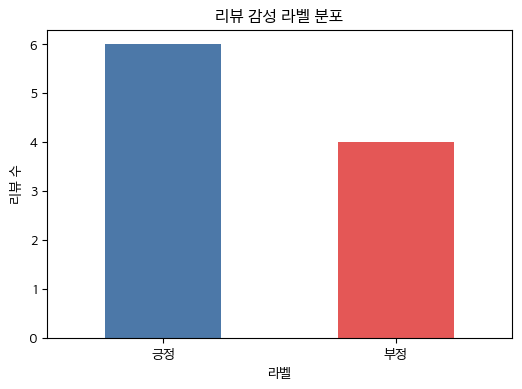

In [6]:
# 라벨 분포 시각화
counts = df['label_name'].value_counts().reindex(['긍정', '부정'])

plt.figure(figsize=(6, 4))
# TODO 4. counts 막대그래프
ax = counts.plot(kind='bar', color=['#4C78A8', '#E45756'], rot=0)
ax.set_title('리뷰 감성 라벨 분포')
ax.set_xlabel('라벨')
ax.set_ylabel('리뷰 수')
plt.show()


## 3. 텍스트 길이 탐색

텍스트 길이는 매우 짧거나 긴 문서, 빈 문자열, 복제된 안내 문구 등을 찾는 데 도움을 줍니다. 여기서는 문자 수와 공백 기준 어절 수를 모두 살펴봅니다.

### 체크포인트 2 — 데이터 구조 답변

1. 행 하나는 영화 리뷰 한 건과 그 리뷰의 고유번호, 감성 라벨, 작성일을 의미한다.
2. `label`은 모델이 다루기 쉬운 수치형 값이고, `label_name`은 사람이 결과와 그래프를 쉽게 해석하도록 돕는 설명형 값이므로 둘을 함께 둔다.
3. 긍정 6건, 부정 4건으로 심하게 치우치지는 않았지만 표본이 10건뿐이고 60:40의 차이가 있으므로 실제 감성분석 모델의 학습 데이터가 충분히 균형 잡혔다고 결론 내릴 수 없다.


In [7]:
# TODO 5. 문자 수(char_len)와 공백 기준 어절 수(word_len) 열 생성
df['char_len'] = df['text'].str.len()
df['word_len'] = df['text'].str.split().str.len()

display(df[['review_id', 'label_name', 'char_len', 'word_len', 'text']])

# 긍정/부정 리뷰 길이 비교
display(df.groupby('label_name')[['char_len', 'word_len']].agg(['count', 'mean', 'min', 'max']).round(2))


,review_id,label_name,char_len,word_len,text
0,1,긍정,28,5,정말 재미있어요! 배우들의 연기가 인상적이었습니다.
1,2,긍정,19,4,스토리는 평범하지만 음악이 좋네요.
2,3,부정,21,4,기대보다 지루했고 결말이 아쉬웠습니다.
3,4,긍정,26,6,영상미는 훌륭합니다. 다만 전개가 조금 느려요.
4,5,부정,20,5,다시는 보고 싶지 않은 영화예요...
5,6,긍정,25,7,가족과 함께 보기 좋은 따뜻한 작품입니다 :)
6,7,부정,24,6,배우는 좋았지만 대사가 잘 들리지 않았어요.
7,8,긍정,22,6,추천합니다! 다음 편도 꼭 보고 싶어요.
8,9,부정,24,5,별로예요. 러닝타임이 너무 길게 느껴집니다.
9,10,긍정,21,5,생각할 거리를 주는 좋은 영화였습니다.


char_len                word_len             
              count   mean min max    count mean min max
label_name                                              
긍정                6  23.50  19  28        6  5.5   4   7
부정                4  22.25  20  24        4  5.0   4   6

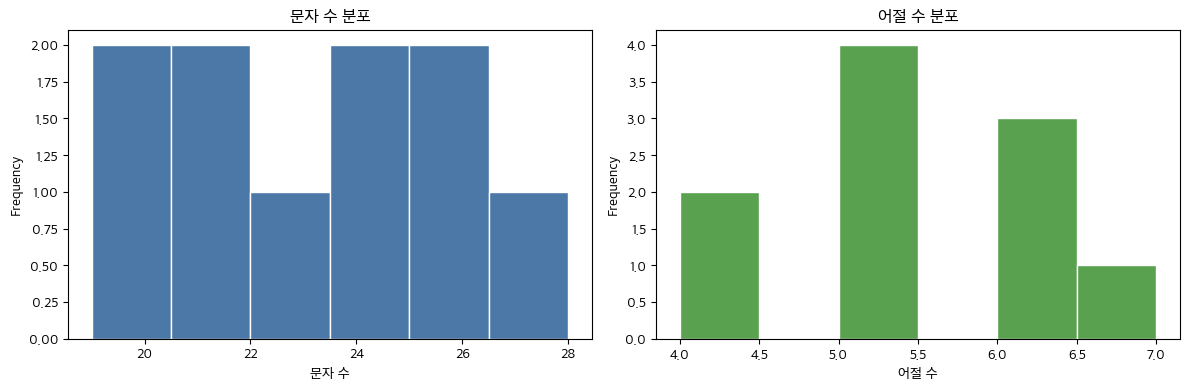

In [8]:
# 길이 분포 비교
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# TODO 6. char_len 히스토그램
df['char_len'].plot(kind='hist', bins=6, ax=axes[0], color='#4C78A8', edgecolor='white')
axes[0].set_title('문자 수 분포')
axes[0].set_xlabel('문자 수')

# 어절 수 분포
df['word_len'].plot(kind='hist', bins=6, ax=axes[1], color='#59A14F', edgecolor='white')
axes[1].set_title('어절 수 분포')
axes[1].set_xlabel('어절 수')

plt.tight_layout()
plt.show()


## 4. 간단한 토큰 빈도와 어휘 다양성

빈도 분석은 코퍼스의 주제와 노이즈를 빠르게 파악하는 출발점입니다. 다만 조사·어미·불용어가 상위에 나타날 수 있으므로, 결과를 그대로 의미 있는 키워드라고 단정하면 안 됩니다.

### 체크포인트 3 — 길이 탐색 답변

문자 수 기준 가장 짧은 리뷰는 2번(19자), 가장 긴 리뷰는 1번(28자)이다. 긴 리뷰도 상세한 감상일 수 있으므로 길이만으로 오류라고 볼 수 없다. 실제 데이터에서는 원문을 확인하면서 빈 문자열, 동일 문구 반복, HTML/광고 삽입, 잘못 합쳐진 문서처럼 길이를 비정상적으로 만든 원인이 있는지 추가로 점검해야 한다.


In [9]:
def simple_tokenize(text):
    """한글/영문/숫자 덩어리를 추출하는 매우 단순한 교육용 토크나이저"""
    return re.findall(r'[가-힣A-Za-z0-9]+', text.lower())

# TODO 7. 모든 리뷰의 토큰을 하나의 리스트로 수집
all_tokens = [token for text in df['text'] for token in simple_tokenize(text)]

freq = Counter(all_tokens)
print('전체 토큰 수:', len(all_tokens))
print('고유 토큰 수:', len(freq))
print('어휘 다양성(type-token ratio):', round(len(freq) / len(all_tokens), 3))
display(pd.DataFrame(freq.most_common(15), columns=['token', 'count']))


전체 토큰 수: 52
고유 토큰 수: 50
어휘 다양성(type-token ratio): 0.962


,token,count
0,보고,2
1,좋은,2
2,정말,1
3,재미있어요,1
4,배우들의,1
5,연기가,1
6,인상적이었습니다,1
7,스토리는,1
8,평범하지만,1
9,음악이,1


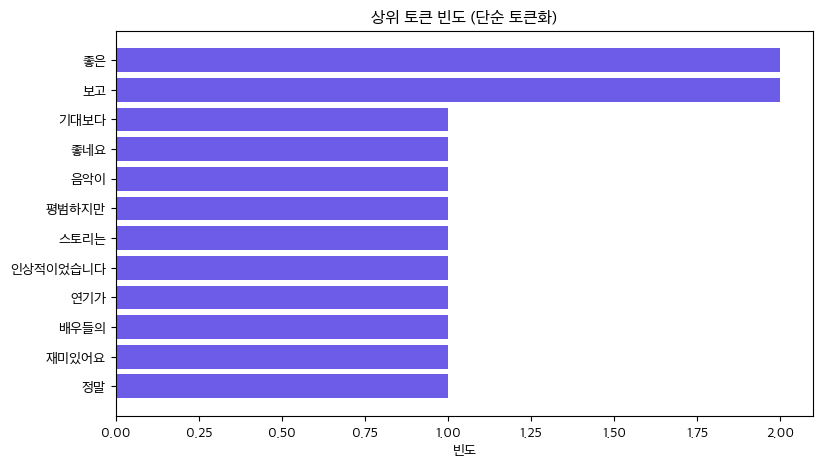

In [10]:
# 상위 토큰 시각화
# TODO 8. freq의 상위 12개 토큰을 데이터프레임으로 변환
freq_df = pd.DataFrame(freq.most_common(12), columns=['token', 'count'])
freq_df = freq_df.sort_values('count')

plt.figure(figsize=(9, 5))
plt.barh(freq_df['token'], freq_df['count'], color='#6C5CE7')
plt.title('상위 토큰 빈도 (단순 토큰화)')
plt.xlabel('빈도')
plt.show()


### 체크포인트 4 — 불용어 후보 답변

`보고`, `좋은`처럼 자주 나타나는 토큰도 문맥에 따라 감성 판단력이 제한적일 수 있다. 이런 토큰을 불용어로 제거하면 특징 공간과 노이즈를 줄일 수 있지만, `보고 싶지 않은`의 부정 맥락이나 `좋은`의 실제 긍정 신호까지 잃어 의미가 왜곡될 수 있다.


### 체크포인트 4 — 빈도와 어휘 다양성 요약

상위 빈도만으로 중요도를 단정할 수 없다. 특히 이 예시는 10건뿐이고 형태소 분석·부정 표현 결합을 하지 않았기 때문에, 불용어 제거 여부는 문맥과 과업 성능을 함께 비교해 결정해야 한다.


## 5. 한글 텍스트와 인코딩 확인

컴퓨터는 문자를 코드로 저장합니다. UTF-8은 가장 널리 쓰이는 문자 인코딩 중 하나이며, 한글을 포함한 다양한 문자를 표현할 수 있습니다. 파일을 잘못된 인코딩으로 읽으면 `�`처럼 깨진 문자가 나타날 수 있습니다.

또한 겉보기에는 같은 글자라도 유니코드 정규화 방식에 따라 내부 코드가 다를 수 있습니다. 데이터 병합·중복 제거 전에 확인할 가치가 있습니다.

In [11]:
text = '한글 NLP'
print('원문:', text)
print('UTF-8 바이트:', text.encode('utf-8'))

# TODO 9. UTF-8 바이트를 문자열로 복원
restored = text.encode('utf-8').decode('utf-8')
print('UTF-8로 복원:', restored)

# 유니코드 정규화 예시
composed = '가'
decomposed = unicodedata.normalize('NFD', composed)
print('겉보기 문자열:', composed, decomposed)
print('문자열 동일 여부:', composed == decomposed)

# TODO 10. 두 문자열을 NFC로 정규화한 뒤 동일한지 확인
print(
    'NFC 정규화 후 동일 여부:',
    unicodedata.normalize('NFC', composed) == unicodedata.normalize('NFC', decomposed),
)


원문: 한글 NLP
UTF-8 바이트: b'\xed\x95\x9c\xea\xb8\x80 NLP'
UTF-8로 복원: 한글 NLP
겉보기 문자열: 가 가
문자열 동일 여부: False
NFC 정규화 후 동일 여부: True


In [12]:
# 간단한 품질 점검 함수: 빈 텍스트, 깨진 문자, URL/이메일/전화번호 패턴 표시
# 실제 개인정보 탐지는 더 엄격한 정책과 사람의 검토가 필요함
def quality_flags(text):
    flags = []
    if not isinstance(text, str) or not text.strip():
        flags.append('빈 텍스트')
        return ', '.join(flags)
    if '�' in text:
        flags.append('인코딩 깨짐 의심')
    if re.search(r'https?://\S+|www\.\S+', text):
        flags.append('URL 포함')
    if re.search(r'[\w.+-]+@[\w-]+\.[\w.-]+', text):
        flags.append('이메일 포함 가능성')
    # TODO 11. 전화번호로 보이는 패턴 탐지
    if re.search(r'\d{2,3}[- ]?\d{3,4}[- ]?\d{4}', text):
        flags.append('전화번호 포함 가능성')
    return ', '.join(flags) if flags else '이상 없음'

df['quality_check'] = df['text'].apply(quality_flags)
display(df[['review_id', 'text', 'quality_check']])


,review_id,text,quality_check
0,1,정말 재미있어요! 배우들의 연기가 인상적이었습니다.,이상 없음
1,2,스토리는 평범하지만 음악이 좋네요.,이상 없음
2,3,기대보다 지루했고 결말이 아쉬웠습니다.,이상 없음
3,4,영상미는 훌륭합니다. 다만 전개가 조금 느려요.,이상 없음
4,5,다시는 보고 싶지 않은 영화예요...,이상 없음
5,6,가족과 함께 보기 좋은 따뜻한 작품입니다 :),이상 없음
6,7,배우는 좋았지만 대사가 잘 들리지 않았어요.,이상 없음
7,8,추천합니다! 다음 편도 꼭 보고 싶어요.,이상 없음
8,9,별로예요. 러닝타임이 너무 길게 느껴집니다.,이상 없음
9,10,생각할 거리를 주는 좋은 영화였습니다.,이상 없음


## 6. 미니 실습: 감성별 자주 등장하는 토큰 비교

아래 분석은 **매우 단순한 탐색**입니다. 리뷰 수가 적고, 형태소 분석·불용어 처리·부정 표현 처리도 하지 않았습니다. 따라서 인과관계나 일반적 성능을 주장할 수 없습니다.

### 체크포인트 5 — 인코딩·품질·윤리 답변

UTF-8을 다른 인코딩으로 읽으면 글자가 깨지거나 디코딩 오류가 발생하고, NFC/NFD를 통일하지 않으면 화면상 같은 한글도 서로 다른 문자열로 비교되어 중복 제거·검색·토큰 집계·모델 입력이 일관되지 않을 수 있다. URL·이메일·전화번호는 개인을 직접 또는 다른 정보와 결합해 식별할 수 있으므로 수집 단계에서 탐지해 이용 목적과 동의 범위를 확인하고, 필요하지 않으면 삭제하거나 마스킹해야 한다. 정규표현식 탐지는 후보를 찾는 보조 수단이므로 최종적으로 정책과 사람의 검토가 필요하다.


In [13]:
def top_tokens_by_label(data, label, n=10):
    texts = data.loc[data['label'] == label, 'text']
    tokens = [tok for text in texts for tok in simple_tokenize(text)]
    return pd.DataFrame(Counter(tokens).most_common(n), columns=['token', 'count'])

# TODO 12. 긍정(1)과 부정(0) 리뷰의 상위 토큰
positive_top = top_tokens_by_label(df, 1)
negative_top = top_tokens_by_label(df, 0)

print('긍정 리뷰 상위 토큰')
display(positive_top)
print('부정 리뷰 상위 토큰')
display(negative_top)


긍정 리뷰 상위 토큰


,token,count
0,좋은,2
1,정말,1
2,재미있어요,1
3,배우들의,1
4,연기가,1
5,인상적이었습니다,1
6,스토리는,1
7,평범하지만,1
8,음악이,1
9,좋네요,1


부정 리뷰 상위 토큰


,token,count
0,기대보다,1
1,지루했고,1
2,결말이,1
3,아쉬웠습니다,1
4,다시는,1
5,보고,1
6,싶지,1
7,않은,1
8,영화예요,1
9,배우는,1


## 7. 실습 정리: 분석 전 점검표

모델을 학습하기 전 아래 질문에 답할 수 있어야 합니다.

- [ ] 데이터의 **출처·수집 목적·이용 허가**를 확인했는가?
- [ ] 개인식별정보(이름, 연락처, 이메일 등)와 민감정보를 점검했는가?
- [ ] 문서/문장/토큰 중 분석 단위를 명확히 정했는가?
- [ ] 결측치·중복·깨진 문자·비정상적으로 긴/짧은 텍스트를 확인했는가?
- [ ] 라벨 분포가 치우쳐 있지 않은가?
- [ ] 결과가 데이터 규모와 전처리 한계에 비추어 과장되지 않았는가?

다음 주차에는 이 데이터를 바탕으로 정규화, 정제, 토큰화와 한글 형태소 분석을 다룹니다.


### 체크포인트 6 — 결과 해석의 한계 답변

긍정 리뷰에서는 `좋은`, `재미있어요`, `훌륭합니다`, 부정 리뷰에서는 `지루했고`, `아쉬웠습니다`, `별로예요` 같은 표현이 관찰되지만 조사·어미가 붙은 토큰과 중립적인 단어도 함께 나타난다. 표본이 매우 작고 문맥·부정 표현·형태소를 처리하지 않았으므로 이 빈도만으로 특정 단어가 감성을 결정한다고 일반화할 수 없다.


## 제출 과제 완료 확인

- [x] TODO 1~12를 작성·실행했다.
- [x] 공백 토큰화와 정규표현식 토큰화의 차이를 설명했다.
- [x] 데이터 구조, 결측치, 중복 및 라벨 분포를 점검했다.
- [x] 문자 수와 어절 수 분포에서 관찰한 특징을 기록했다.
- [x] 상위 빈도 토큰 중 불용어 후보와 그 근거를 설명했다.
- [x] UTF-8·NFC 정규화가 필요한 이유를 설명했다.
- [x] 데이터 품질·개인정보·저작권 관점에서 주의할 점을 기록했다.

### 도전 과제

아래 셀에서 리뷰 6건 추가, 반복 문자 탐지, 공백/Kiwi/Okt 토큰화 비교, 데이터 카드 작성을 수행한다.


In [14]:
# @title 도전 과제용 원본 데이터
import pandas as pd
import re
from collections import Counter

reviews = [
    (1, '정말 재미있어요! 배우들의 연기가 인상적이었습니다.', 1, '2026-08-25'),
    (2, '스토리는 평범하지만 음악이 좋네요.', 1, '2026-08-25'),
    (3, '기대보다 지루했고 결말이 아쉬웠습니다.', 0, '2026-08-26'),
    (4, '영상미는 훌륭합니다. 다만 전개가 조금 느려요.', 1, '2026-08-26'),
    (5, '다시는 보고 싶지 않은 영화예요...', 0, '2026-08-27'),
    (6, '가족과 함께 보기 좋은 따뜻한 작품입니다 :)', 1, '2026-08-27'),
    (7, '배우는 좋았지만 대사가 잘 들리지 않았어요.', 0, '2026-08-28'),
    (8, '추천합니다! 다음 편도 꼭 보고 싶어요.', 1, '2026-08-28'),
    (9, '별로예요. 러닝타임이 너무 길게 느껴집니다.', 0, '2026-08-29'),
    (10, '생각할 거리를 주는 좋은 영화였습니다.', 1, '2026-08-29'),
]

df_base = pd.DataFrame(reviews, columns=['review_id', 'text', 'label', 'date'])
df_base['date'] = pd.to_datetime(df_base['date'])

print('원본 데이터 건수:', len(df_base))
df_base


원본 데이터 건수: 10


,review_id,text,label,date
0,1,정말 재미있어요! 배우들의 연기가 인상적이었습니다.,1,2026-08-25
1,2,스토리는 평범하지만 음악이 좋네요.,1,2026-08-25
2,3,기대보다 지루했고 결말이 아쉬웠습니다.,0,2026-08-26
3,4,영상미는 훌륭합니다. 다만 전개가 조금 느려요.,1,2026-08-26
4,5,다시는 보고 싶지 않은 영화예요...,0,2026-08-27
5,6,가족과 함께 보기 좋은 따뜻한 작품입니다 :),1,2026-08-27
6,7,배우는 좋았지만 대사가 잘 들리지 않았어요.,0,2026-08-28
7,8,추천합니다! 다음 편도 꼭 보고 싶어요.,1,2026-08-28
8,9,별로예요. 러닝타임이 너무 길게 느껴집니다.,0,2026-08-29
9,10,생각할 거리를 주는 좋은 영화였습니다.,1,2026-08-29


라벨 분포 비교


,추가 전,추가 후
label,,
긍정,6,9
부정,4,7


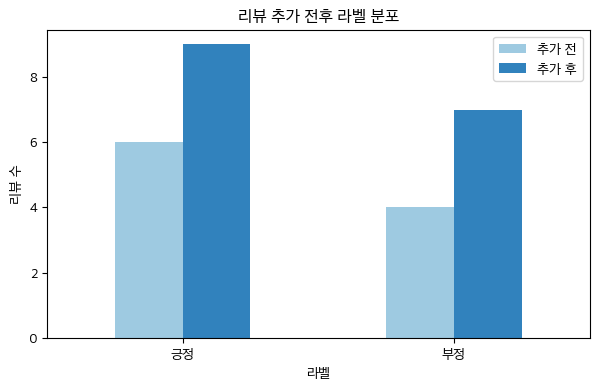

추가 전 상위 토큰


,token,count
0,보고,2
1,좋은,2
2,정말,1
3,재미있어요,1
4,배우들의,1
5,연기가,1
6,인상적이었습니다,1
7,스토리는,1
8,평범하지만,1
9,음악이,1


추가 후 상위 토큰


,token,count
0,좋은,3
1,정말,2
2,배우들의,2
3,아쉬웠습니다,2
4,보고,2
5,함께,2
6,좋았지만,2
7,영화였습니다,2
8,재미있어요,1
9,연기가,1


해석: 긍정 6/부정 4에서 긍정 9/부정 7로 표본 수와 균형이 개선되었습니다.
새 리뷰의 표현이 빈도표에 들어오지만, 16건도 일반화하기에는 매우 작은 표본입니다.


In [15]:
# @title 1. 리뷰 6개 추가 후 라벨 분포·상위 토큰 비교
new_reviews = [
    (11, '배경 음악과 촬영 기법이 정말 인상 깊었습니다.', 1, '2026-08-30'),
    (12, '개연성이 부족하고 캐릭터가 매력이 없어요.', 0, '2026-08-30'),
    (13, '연출은 좋았지만 결말 처리가 아쉬웠습니다.', 0, '2026-08-31'),
    (14, '몰입감이 대단했고 배우들의 연기력이 훌륭했어요!', 1, '2026-08-31'),
    (15, '기대했던 것보다 훨씬 실망스러운 영화였습니다.', 0, '2026-09-01'),
    (16, '아이들과 함께 보기에 딱 좋은 영화였어요 :)', 1, '2026-09-01'),
]

new_df = pd.DataFrame(new_reviews, columns=df_base.columns)
new_df['date'] = pd.to_datetime(new_df['date'])
df_expanded = pd.concat([df_base, new_df], ignore_index=True)

label_comparison = pd.concat(
    [
        df_base['label'].value_counts().rename('추가 전'),
        df_expanded['label'].value_counts().rename('추가 후'),
    ],
    axis=1,
).rename(index={1: '긍정', 0: '부정'}).fillna(0).astype(int)
print('라벨 분포 비교')
display(label_comparison)

ax = label_comparison.plot(kind='bar', figsize=(7, 4), rot=0, color=['#9ECAE1', '#3182BD'])
ax.set_title('리뷰 추가 전후 라벨 분포')
ax.set_xlabel('라벨')
ax.set_ylabel('리뷰 수')
plt.show()

def corpus_top_tokens(data, n=12):
    tokens = [tok for text in data['text'] for tok in simple_tokenize(text)]
    return pd.DataFrame(Counter(tokens).most_common(n), columns=['token', 'count'])

print('추가 전 상위 토큰')
display(corpus_top_tokens(df_base))
print('추가 후 상위 토큰')
display(corpus_top_tokens(df_expanded))

print('해석: 긍정 6/부정 4에서 긍정 9/부정 7로 표본 수와 균형이 개선되었습니다.')
print('새 리뷰의 표현이 빈도표에 들어오지만, 16건도 일반화하기에는 매우 작은 표본입니다.')


In [16]:
# @title 2. quality_flags에 반복 문자 탐지 규칙 추가
def quality_flags_extended(text):
    flags = []
    if not isinstance(text, str) or not text.strip():
        return '빈 텍스트'
    if '�' in text:
        flags.append('인코딩 깨짐 의심')
    if re.search(r'https?://\S+|www\.\S+', text):
        flags.append('URL 포함')
    if re.search(r'[\w.+-]+@[\w-]+\.[\w.-]+', text):
        flags.append('이메일 포함 가능성')
    if re.search(r'\d{2,3}[- ]?\d{3,4}[- ]?\d{4}', text):
        flags.append('전화번호 포함 가능성')
    # 같은 문자가 3회 이상 연속되면 반복 문자 후보로 표시: ㅋㅋㅋㅋ, !!!!, ...
    if re.search(r'(.)\1{2,}', text):
        flags.append('반복 문자 포함')
    return ', '.join(flags) if flags else '이상 없음'

df_expanded['quality_check'] = df_expanded['text'].apply(quality_flags_extended)
display(df_expanded[['review_id', 'text', 'quality_check']])

repeat_examples = pd.Series(['재밌어요ㅋㅋㅋㅋ', '최고!!!!', '영화예요...', '2026년 111회 상영'])
print('반복 문자 탐지 예시')
display(pd.DataFrame({'text': repeat_examples, 'flag': repeat_examples.map(quality_flags_extended)}))
print('오탐 가능성: 111처럼 실제로 유효한 숫자 반복도 노이즈로 표시될 수 있고, ㅋㅋ·ㅠㅠ 같은 표현은 감성 신호일 수 있으므로 자동 삭제하지 않고 검토해야 합니다.')


,review_id,text,quality_check
0,1,정말 재미있어요! 배우들의 연기가 인상적이었습니다.,이상 없음
1,2,스토리는 평범하지만 음악이 좋네요.,이상 없음
2,3,기대보다 지루했고 결말이 아쉬웠습니다.,이상 없음
3,4,영상미는 훌륭합니다. 다만 전개가 조금 느려요.,이상 없음
4,5,다시는 보고 싶지 않은 영화예요...,반복 문자 포함
5,6,가족과 함께 보기 좋은 따뜻한 작품입니다 :),이상 없음
6,7,배우는 좋았지만 대사가 잘 들리지 않았어요.,이상 없음
7,8,추천합니다! 다음 편도 꼭 보고 싶어요.,이상 없음
8,9,별로예요. 러닝타임이 너무 길게 느껴집니다.,이상 없음
9,10,생각할 거리를 주는 좋은 영화였습니다.,이상 없음


반복 문자 탐지 예시


,text,flag
0,재밌어요ㅋㅋㅋㅋ,반복 문자 포함
1,최고!!!!,반복 문자 포함
2,영화예요...,반복 문자 포함
3,2026년 111회 상영,반복 문자 포함


오탐 가능성: 111처럼 실제로 유효한 숫자 반복도 노이즈로 표시될 수 있고, ㅋㅋ·ㅠㅠ 같은 표현은 감성 신호일 수 있으므로 자동 삭제하지 않고 검토해야 합니다.


In [17]:
# @title 3. 공백 토큰화와 Kiwi·KoNLPy(Okt) 형태소 분석 비교
import importlib.util
import subprocess
import sys

required = {'kiwipiepy': 'kiwipiepy', 'konlpy': 'konlpy'}
missing = [package for module, package in required.items() if importlib.util.find_spec(module) is None]
if missing:
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', *missing])

from kiwipiepy import Kiwi

comparison_text = '배우들의 연기가 인상적이었습니다.'
kiwi = Kiwi()

space_tokens = comparison_text.split()
kiwi_tokens = [(token.form, token.tag) for token in kiwi.tokenize(comparison_text)]
if 'google.colab' in sys.modules:
    from konlpy.tag import Okt
    okt_tokens = Okt().pos(comparison_text, norm=True, stem=True)
else:
    okt_tokens = 'Google Colab에서 이 셀을 실행하면 실제 Okt 결과가 표시됩니다.'

print('원문:', comparison_text)
print('공백 토큰화:', space_tokens)
print('Kiwi 형태소:', kiwi_tokens)
print('Okt 형태소:', okt_tokens)
print('해석: 공백 토큰화는 조사와 어미가 붙은 어절을 그대로 남기지만, 형태소 분석기는 배우/들/의, 연기/가처럼 의미 단위와 문법 단위를 분리합니다.')
print('분석기마다 사전과 태그 체계가 달라 결과가 조금씩 다르므로, 과업과 데이터에 맞춰 선택하고 버전을 기록해야 합니다.')


원문: 배우들의 연기가 인상적이었습니다.
공백 토큰화: ['배우들의', '연기가', '인상적이었습니다.']
Kiwi 형태소: [('배우', 'NNG'), ('들', 'XSN'), ('의', 'JKG'), ('연기', 'NNG'), ('가', 'JKS'), ('인상', 'NNG'), ('적', 'XSN'), ('이', 'VCP'), ('었', 'EP'), ('습니다', 'EF'), ('.', 'SF')]
Okt 형태소: Google Colab에서 이 셀을 실행하면 실제 Okt 결과가 표시됩니다.
해석: 공백 토큰화는 조사와 어미가 붙은 어절을 그대로 남기지만, 형태소 분석기는 배우/들/의, 연기/가처럼 의미 단위와 문법 단위를 분리합니다.
분석기마다 사전과 태그 체계가 달라 결과가 조금씩 다르므로, 과업과 데이터에 맞춰 선택하고 버전을 기록해야 합니다.


In [18]:
# @title 4. 저장소 README 데이터 카드 확인
from pathlib import Path

readme_path = Path('README.md')
if readme_path.exists():
    readme_content = readme_path.read_text(encoding='utf-8')
    print(readme_content)
else:
    print('README.md는 GitHub 저장소 루트에 함께 제출합니다.')

print('데이터 카드에는 출처, 라이선스, 개인정보 처리, 데이터 구성, 알려진 한계를 명시했습니다.')


# NLP Practice

자연어처리 수업 실습과 제출용 노트북을 정리한 저장소입니다.

## 노트북

- `NLP_week01_제출용.ipynb`: 1주차 실습
- `NLP_week02_제출용.ipynb`: 2주차 텍스트 데이터 이해 실습 및 도전 과제

## 2주차 실행 방법

Google Colab에서 `NLP_week02_제출용.ipynb`를 연 뒤 위에서 아래로 모든 셀을 실행합니다. 기본 실습은 `pandas`, `matplotlib`을 사용하며, 도전 과제의 형태소 분석 비교 셀은 필요한 경우 `kiwipiepy`와 `konlpy`를 자동으로 설치합니다.

## 데이터 카드

### 출처와 수집 목적

- 데이터셋 이름: 영화 리뷰 감성 분석 교육용 예시 데이터
- 원본 10건과 추가 6건 모두 수업 실습을 위해 직접 작성한 문장입니다.
- 외부 데이터셋이나 실제 이용자 리뷰를 수집·병합하지 않았습니다.
- 작성 기간: 2026-08-25 ~ 2026-09-01

### 이용 조건과 라이선스

- 예시 문장은 교육용 실습을 위해 작성했습니다.
- 향후 외부 데이터를 병합할 경우 원 제공처, 원문 URL, 수집일, 라이선스, 상업적 이용 및 재배포 조건을 별도로 확인하고 기록해야 합니다.

### 개인정보 처리

- 현재 예시 데이터에는 실명, 연락처, 이메일, 주소 등 개인식별정보를 포함하지 않았습니다.
- 노트북은 URL, 이메일, 전화번호처럼 보이는 패턴을 탐지하는 품질 점검 예시를 포함합니다.
- 정규표현식은 후보 탐지 도구일 뿐이므로 실제 데이터에는 정책에 따른 사람의 검토와 삭제·마스킹 절차가 추가로 필요합니다.

### 데이터 구성

| 구분 | 건수 |
| --- | ---: |
| 원본 | 10 |
| 추가 | 6 |
| 전체 | 16 |
| 긍정(1) | 9 |
| 부정(0) | 7 |

주요 열은 `review_id`(고유번호), `text`(리뷰 본문), `label`(1=긍정, 0=부정), `date`(작성일)입니다.

##